<a href="https://colab.research.google.com/github/arnavon2005/Army_Provost_ML_Project/blob/main/04_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ==============================================================================
# PROJECT:
# Control Room - Applying Machine Learning Algorithms for Enabling
# Indian Army Provost Functioning
# ==============================================================================
#
# PHASE 5 : EXPLORATORY DATA ANALYSIS (EDA)
#
# Developer : Arnav Sharma
# Platform  : Google Colab
#
# Purpose:
# This notebook performs Exploratory Data Analysis (EDA) on the cleaned
# Chicago Crimes and Montgomery Police Dispatch datasets.
#
# Cleaned datasets generated from:
# 03_Data_Cleaning.ipynb
#
# ==============================================================================

In [8]:
# ==========================================================
# SECTION 1 : MOUNT GOOGLE DRIVE
# ==========================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [18]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/Army_Provost_ML_Project")

DATA_PATH = PROJECT_PATH / "Datasets"

RAW_DATASET_PATH = DATA_PATH / "Raw"
CLEAN_DATASET_PATH = DATA_PATH / "Cleaned"

REPORTS_PATH = PROJECT_PATH / "Reports"
FIGURES_PATH = PROJECT_PATH / "Figures"
MODELS_PATH = PROJECT_PATH / "Models"
OUTPUTS_PATH = PROJECT_PATH / "Outputs"

# Create folders if they don't exist
for folder in [FIGURES_PATH, REPORTS_PATH, MODELS_PATH, OUTPUTS_PATH]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Project Path :", PROJECT_PATH)
print("Raw Dataset Path :", RAW_DATASET_PATH)
print("Clean Dataset Path :", CLEAN_DATASET_PATH)
print("Figures Path :", FIGURES_PATH)
print("=" * 60)

Project Path : /content/drive/MyDrive/Army_Provost_ML_Project
Raw Dataset Path : /content/drive/MyDrive/Army_Provost_ML_Project/Datasets/Raw
Clean Dataset Path : /content/drive/MyDrive/Army_Provost_ML_Project/Datasets/Cleaned
Figures Path : /content/drive/MyDrive/Army_Provost_ML_Project/Figures


In [10]:
# ==========================================================
# SECTION 3 : IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [19]:
# ==========================================================
# SECTION 4 : LOAD CLEANED DATASETS
# ==========================================================

print("=" * 80)
print("LOADING CLEANED DATASETS")
print("=" * 80)

chicago_df = pd.read_csv(
    CLEAN_DATASET_PATH / "chicago_crimes_cleaned.csv",
    low_memory=False
)

montgomery_df = pd.read_csv(
    CLEAN_DATASET_PATH / "montgomery_dispatch_cleaned.csv",
    low_memory=False
)

print("\nDatasets loaded successfully.\n")

print("Chicago Crimes Shape:")
print(chicago_df.shape)

print()

print("Montgomery Dispatch Shape:")
print(montgomery_df.shape)

LOADING CLEANED DATASETS

Datasets loaded successfully.

Chicago Crimes Shape:
(8602734, 22)

Montgomery Dispatch Shape:
(1886836, 26)


In [20]:
# ==========================================================
# SECTION 5 : VERIFY DATA
# ==========================================================

print("=" * 80)
print("CHICAGO DATASET")
print("=" * 80)

display(chicago_df.head())

print()

print("=" * 80)
print("MONTGOMERY DATASET")
print("=" * 80)

display(montgomery_df.head())

CHICAGO DATASET


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14269678,JK342166,2026-07-20 00:00:00,001XX E WACKER DR,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL / MOTEL,False,False,114,1.0,42.0,32.0,02,1177683.0,1902638.0,2026,2026-07-27 15:43:52,41.888165,-87.622940,"(41.888165132, -87.622937212)"
1,14267487,JK340097,2026-07-20 00:00:00,084XX S MARYLAND AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,632,6.0,8.0,44.0,14,1183361.0,1849252.0,2026,2026-07-27 15:43:52,41.741540,-87.603750,"(41.741539131, -87.603750482)"
2,14267485,JK340089,2026-07-20 00:00:00,105XX S WABASH AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,512,5.0,9.0,49.0,08B,1178438.0,1835166.0,2026,2026-07-27 15:43:52,41.703000,-87.622215,"(41.70299844, -87.622214313)"
3,14268664,JK341413,2026-07-20 00:00:00,091XX S LAFAYETTE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,634,6.0,9.0,49.0,06,1177542.0,1844332.0,2026,2026-07-27 15:43:52,41.728172,-87.625220,"(41.728171435, -87.625219193)"
4,14269513,JK342626,2026-07-20 00:00:00,028XX N KIMBALL AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,APARTMENT,False,False,1412,14.0,35.0,21.0,26,1153219.0,1919032.0,2026,2026-07-27 15:43:52,41.933674,-87.712340,"(41.933672358, -87.712341606)"



MONTGOMERY DATASET


,Incident_ID,Crime Reports,Crash Reports,Start Time,End Time,Priority,Initial Type,Close Type,Address,City,State,Zip,Longitude,Latitude,Police District Number,Beat,PRA,CallTime CallRoute,Calltime Dispatch,Calltime Arrive,Calltime Cleared,CallRoute Dispatch,Dispatch Arrive,Arrive Cleared,Disposition Desc,Location
0,P2600225594,NaN,NaN,2026-07-29 00:25:24,2026-07-29 00:35:05,2,TRAFFIC/TRANSPORTATION INCIDENT,TRAFFIC/TRANSPORTATION INCIDENT,18500 BLK BOYSENBERRY DR,GAITHERSBURG,MD,20879,-77.2071,39.15975,6D,R1,766,225.0,261.0,NaN,581.0,36.0,NaN,NaN,COLOTH-DAMAG-PRKG-HITRUN,POINT (-77.2071 39.1598)
1,P2600225531,NaN,NaN,2026-07-28 22:39:32,2026-07-29 00:32:39,1,"WANTED PERSON, VEHICLE","WANTED PERSON, VEHICLE",10500 BLK CONNECTICUT AVE,KENSINGTON,MD,20895,-77.0766,39.02748,2D,D1,179,349.0,846.0,1427.0,6787.0,497.0,580.0,5359.0,OTHERMISCELLANEOUS,POINT (-77.0766 39.0275)
2,P2600225569,NaN,NaN,2026-07-28 23:45:58,2026-07-29 00:32:26,1,CDS,CDS,11200 BLK GEORGIA AVE,SILVER SPRING,MD,20902,NaN,NaN,4D,L2,354,298.0,591.0,2101.0,2788.0,292.0,1509.0,687.0,SUSPICIOUSSIT/PRSON/VEH,POINT (0 0)
3,P2600225587,NaN,NaN,2026-07-29 00:12:14,2026-07-29 00:29:40,1,"SUSPICIOUS CIRC, PERSONS, VEHICLE","SUSPICIOUS CIRC, PERSONS, VEHICLE",1100 BLK MAPLE AVE,ROCKVILLE,MD,20851,NaN,NaN,1D,A2,292,191.0,279.0,953.0,1046.0,88.0,674.0,92.0,OTHERMISCELLANEOUS,POINT (0 0)
4,P2600225575,NaN,NaN,2026-07-28 23:55:39,2026-07-29 00:28:49,0,ASLTJA,ASLTJA,1 BLK FEATHERWOOD CT,SILVER SPRING,MD,20904,-76.9723,39.05889,3D,I1,147,150.0,177.0,356.0,1990.0,26.0,178.0,1633.0,AGGASSLTFRARMSPS/PTNR,POINT (-76.9723 39.0589)


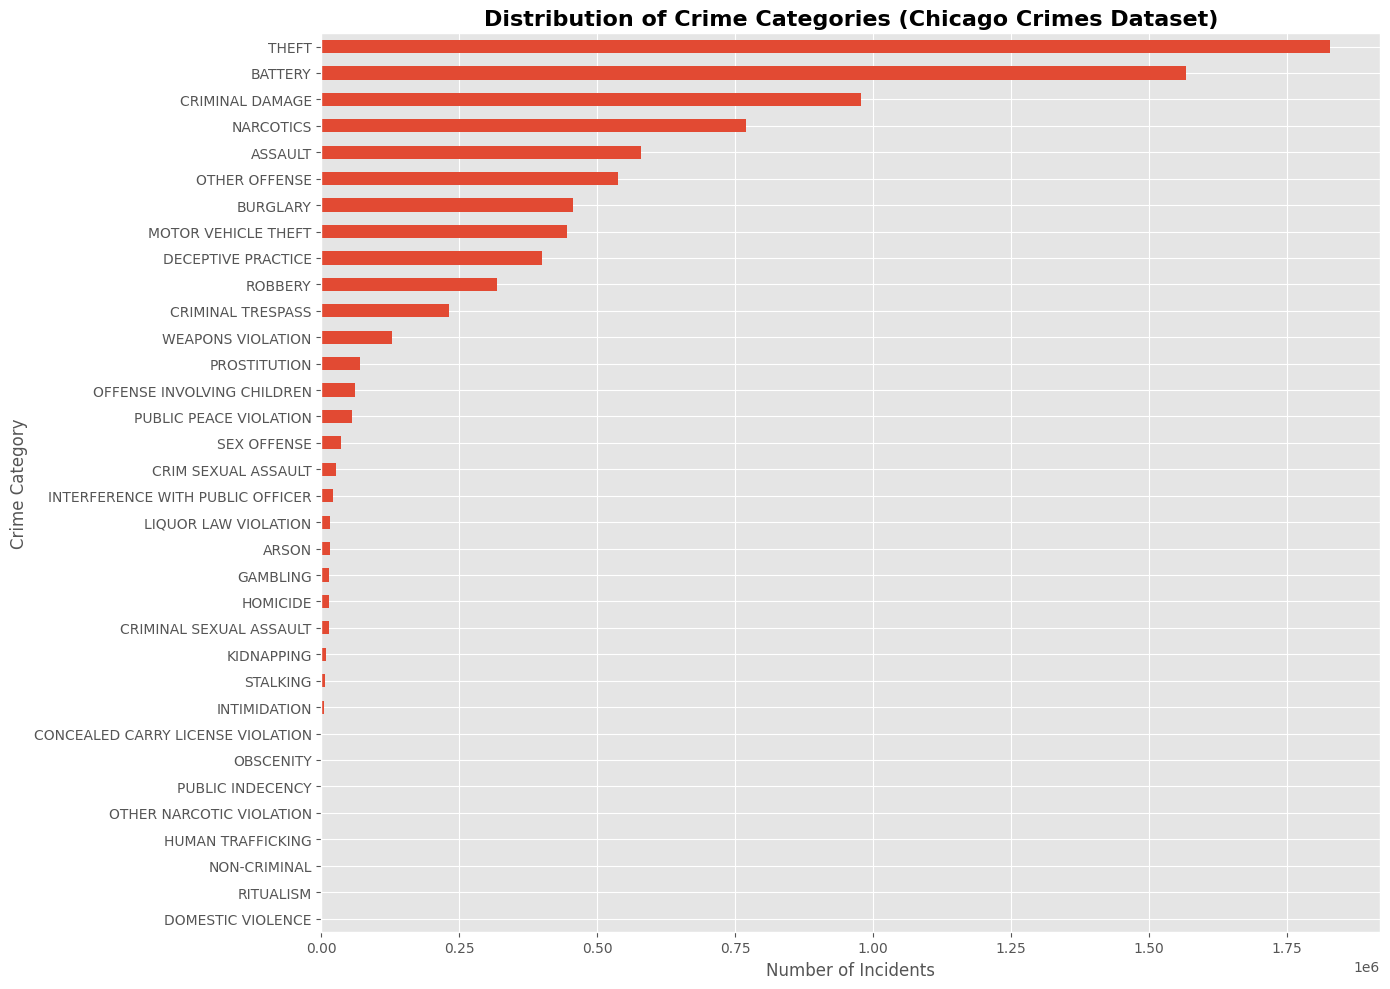

,Incident Count
Primary Type,
THEFT,1827377
BATTERY,1567212
CRIMINAL DAMAGE,977357
NARCOTICS,768704
ASSAULT,580094
OTHER OFFENSE,537540
BURGLARY,455436
MOTOR VEHICLE THEFT,444725
DECEPTIVE PRACTICE,400071


In [21]:
# ==========================================================
# EDA 1 : TOP CRIME CATEGORIES (CHICAGO)
# ==========================================================

import matplotlib.pyplot as plt

# Count incidents
crime_counts = (
    chicago_df["Primary Type"]
    .value_counts()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(14,10))

crime_counts.plot(kind="barh")

plt.title("Distribution of Crime Categories (Chicago Crimes Dataset)",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Incidents", fontsize=12)
plt.ylabel("Crime Category", fontsize=12)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# Display counts
display(
    crime_counts.to_frame(name="Incident Count")
)

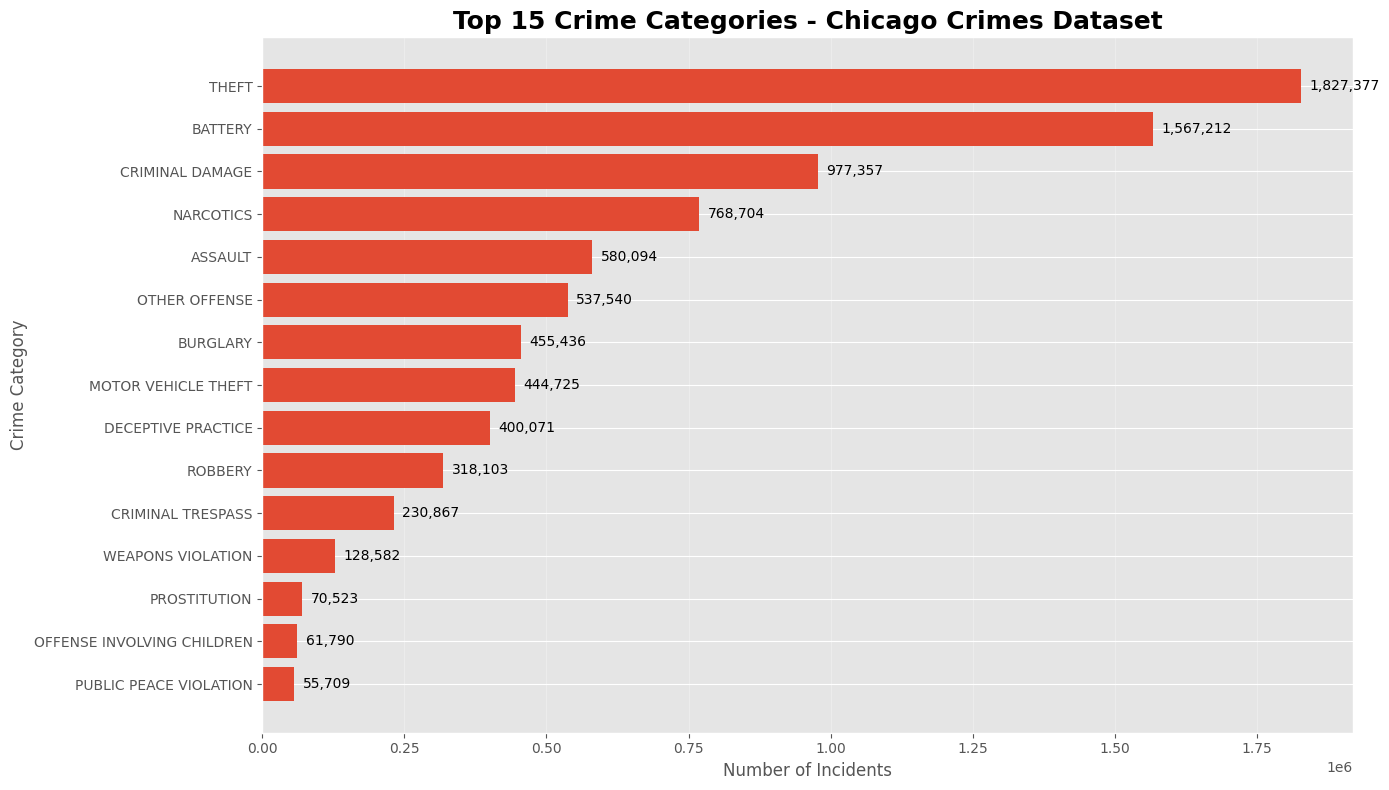

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Top15_Chicago_Crime_Categories.png


,Incident Count,Percentage
Primary Type,,
THEFT,1827377,21.24
BATTERY,1567212,18.22
CRIMINAL DAMAGE,977357,11.36
NARCOTICS,768704,8.94
ASSAULT,580094,6.74
OTHER OFFENSE,537540,6.25
BURGLARY,455436,5.29
MOTOR VEHICLE THEFT,444725,5.17
DECEPTIVE PRACTICE,400071,4.65


In [23]:
# ==========================================================
# EDA 2 : TOP 15 CRIME CATEGORIES (PROFESSIONAL)
# ==========================================================

import matplotlib.pyplot as plt

# -------------------------------
# Top 15 crime categories
# -------------------------------

top15_crimes = chicago_df["Primary Type"].value_counts().head(15)

# -------------------------------
# Create Figure
# -------------------------------

plt.figure(figsize=(14,8))

bars = plt.barh(
    top15_crimes.index[::-1],
    top15_crimes.values[::-1]
)

# -------------------------------
# Add value labels
# -------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 15000,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center',
        fontsize=10
    )

# -------------------------------
# Formatting
# -------------------------------

plt.title(
    "Top 15 Crime Categories - Chicago Crimes Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Incidents", fontsize=12)

plt.ylabel("Crime Category", fontsize=12)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# -------------------------------
# Save Figure
# -------------------------------

figure_path = FIGURES_PATH / "Top15_Chicago_Crime_Categories.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# -------------------------------
# Percentage contribution
# -------------------------------

crime_summary = (
    chicago_df["Primary Type"]
    .value_counts()
    .head(15)
    .to_frame(name="Incident Count")
)

crime_summary["Percentage"] = (
    crime_summary["Incident Count"]
    / len(chicago_df)
    * 100
).round(2)

display(crime_summary)

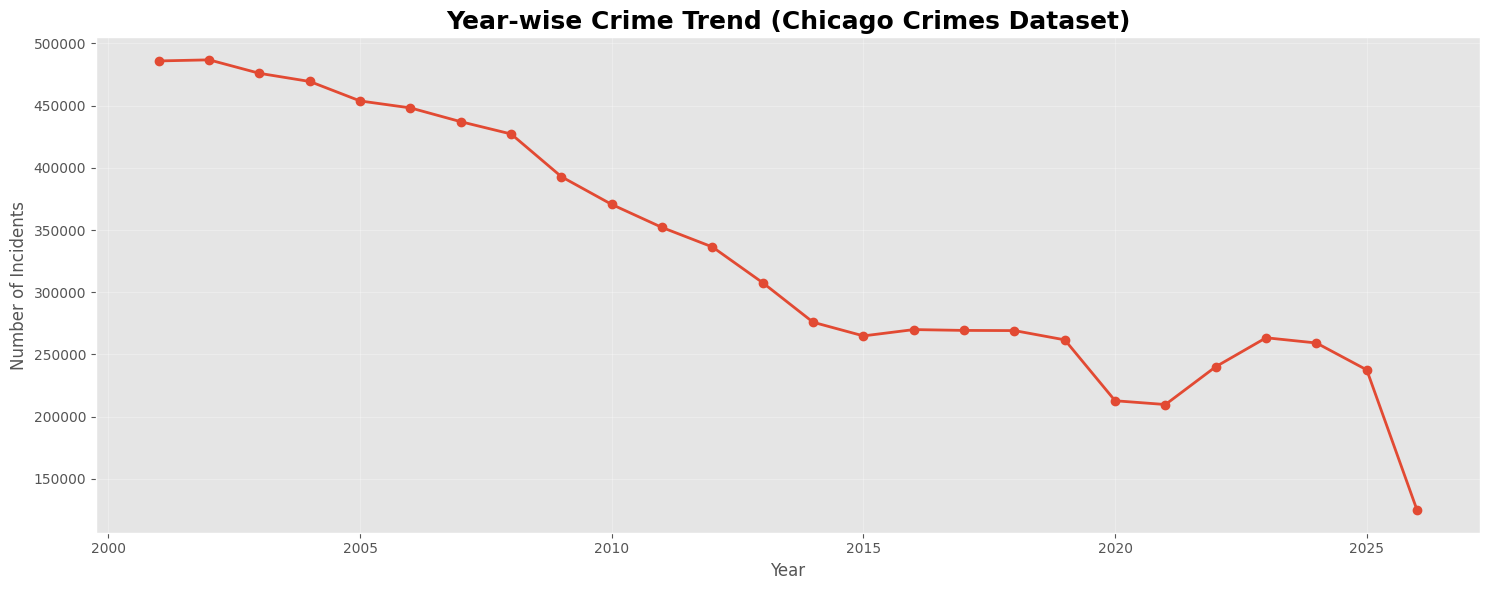

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Yearwise_Crime_Trend.png


,Incident Count
Year,
2001,485969
2002,486839
2003,476006
2004,469444
2005,453794
2006,448204
2007,437111
2008,427224
2009,392868


In [25]:
# ==========================================================
# EDA 3 : YEAR-WISE CRIME TREND
# ==========================================================

import matplotlib.pyplot as plt

# -------------------------------
# Count incidents per year
# -------------------------------

yearly_crimes = (
    chicago_df["Year"]
    .value_counts()
    .sort_index()
)

# -------------------------------
# Create Figure
# -------------------------------

plt.figure(figsize=(15,6))

plt.plot(
    yearly_crimes.index,
    yearly_crimes.values,
    marker="o",
    linewidth=2
)

# -------------------------------
# Formatting
# -------------------------------

plt.title(
    "Year-wise Crime Trend (Chicago Crimes Dataset)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

# -------------------------------
# Save Figure
# -------------------------------

figure_path = FIGURES_PATH / "Yearwise_Crime_Trend.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Figure saved successfully:")
print(figure_path)
print("=" * 70)

# -------------------------------
# Display yearly counts
# -------------------------------

display(
    yearly_crimes.to_frame(name="Incident Count")
)

In [26]:
# ==========================================================
# Convert Date column back to datetime
# ==========================================================

chicago_df["Date"] = pd.to_datetime(
    chicago_df["Date"],
    errors="coerce"
)

print("Date datatype:", chicago_df["Date"].dtype)

Date datatype: datetime64[ns]


In [27]:
# ==========================================================
# Create Month Column
# ==========================================================

chicago_df["Month"] = chicago_df["Date"].dt.month

print("Month column created successfully.")

Month column created successfully.


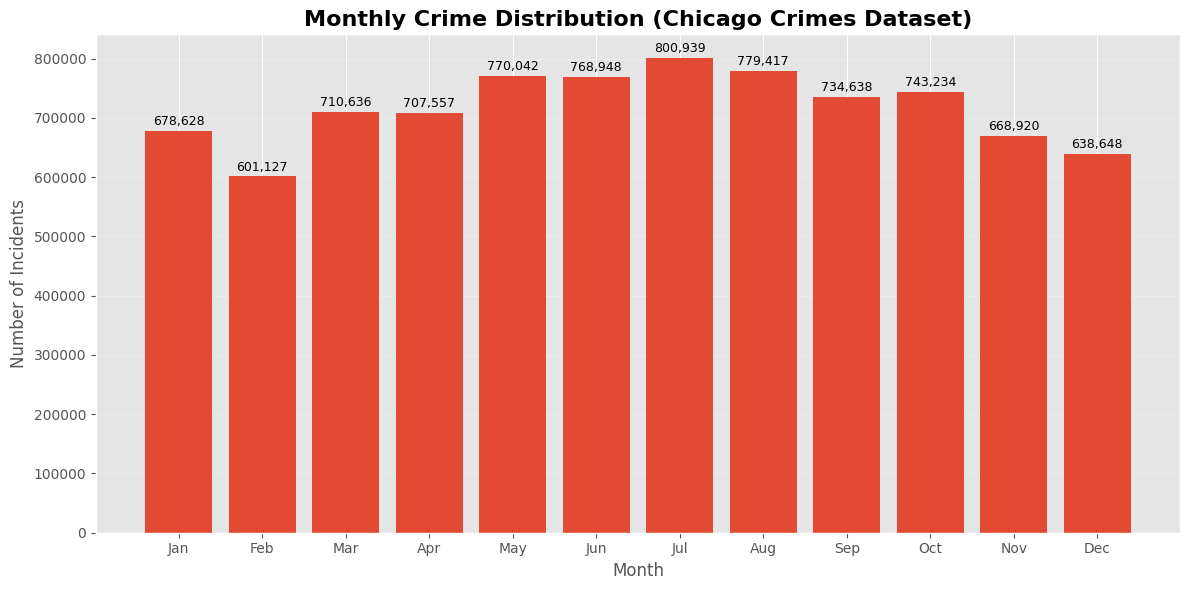

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Monthly_Crime_Distribution.png


,Incident Count
Month,
Jan,678628
Feb,601127
Mar,710636
Apr,707557
May,770042
Jun,768948
Jul,800939
Aug,779417
Sep,734638


In [28]:
# ==========================================================
# EDA 4 : MONTHLY CRIME DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

# --------------------------------
# Month Names
# --------------------------------

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

monthly_crime = (
    chicago_df["Month"]
    .value_counts()
    .sort_index()
)

monthly_crime.index = monthly_crime.index.map(month_names)

# --------------------------------
# Plot
# --------------------------------

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_crime.index,
    monthly_crime.values
)

# --------------------------------
# Add value labels
# --------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10000,
        f"{height:,}",
        ha="center",
        fontsize=9
    )

# --------------------------------
# Formatting
# --------------------------------

plt.title(
    "Monthly Crime Distribution (Chicago Crimes Dataset)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# --------------------------------
# Save Figure
# --------------------------------

figure_path = FIGURES_PATH / "Monthly_Crime_Distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# --------------------------------
# Display Table
# --------------------------------

display(
    monthly_crime.to_frame(name="Incident Count")
)

In [29]:
# ==========================================================
# Create Day of Week Column
# ==========================================================

chicago_df["DayOfWeek"] = chicago_df["Date"].dt.day_name()

print("DayOfWeek column created successfully.")

DayOfWeek column created successfully.


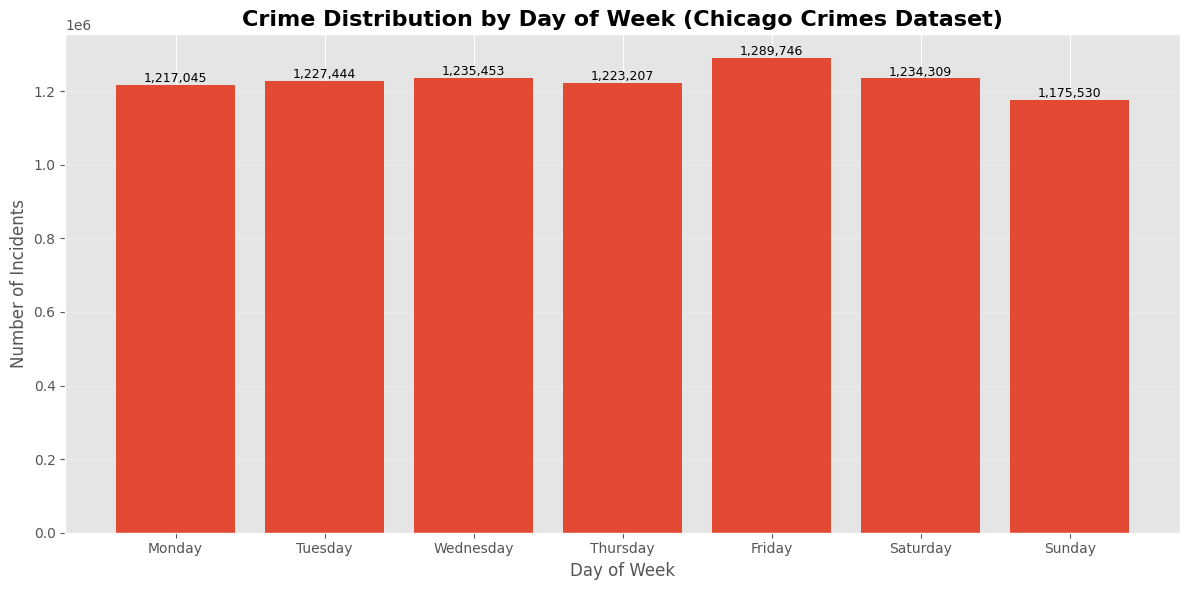

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/DayOfWeek_Crime_Distribution.png


,Incident Count
DayOfWeek,
Monday,1217045
Tuesday,1227444
Wednesday,1235453
Thursday,1223207
Friday,1289746
Saturday,1234309
Sunday,1175530


In [31]:
# ==========================================================
# EDA 5 : DAY OF WEEK CRIME DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

# --------------------------------
# Correct Day Order
# --------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daywise_crime = (
    chicago_df["DayOfWeek"]
    .value_counts()
    .reindex(day_order)
)

# --------------------------------
# Plot
# --------------------------------

plt.figure(figsize=(12,6))

bars = plt.bar(
    daywise_crime.index,
    daywise_crime.values
)

# --------------------------------
# Add Value Labels
# --------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 8000,
        f"{height:,}",
        ha="center",
        fontsize=9
    )

# --------------------------------
# Formatting
# --------------------------------

plt.title(
    "Crime Distribution by Day of Week (Chicago Crimes Dataset)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Incidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# --------------------------------
# Save Figure
# --------------------------------

figure_path = FIGURES_PATH / "DayOfWeek_Crime_Distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# --------------------------------
# Display Table
# --------------------------------

display(
    daywise_crime.to_frame(name="Incident Count")
)

In [32]:
# ==========================================================
# Create Hour Column
# ==========================================================

chicago_df["Hour"] = chicago_df["Date"].dt.hour

print("Hour column created successfully.")

display(
    chicago_df[["Date", "Hour"]].head()
)

Hour column created successfully.


,Date,Hour
0,2026-07-20,0
1,2026-07-20,0
2,2026-07-20,0
3,2026-07-20,0
4,2026-07-20,0


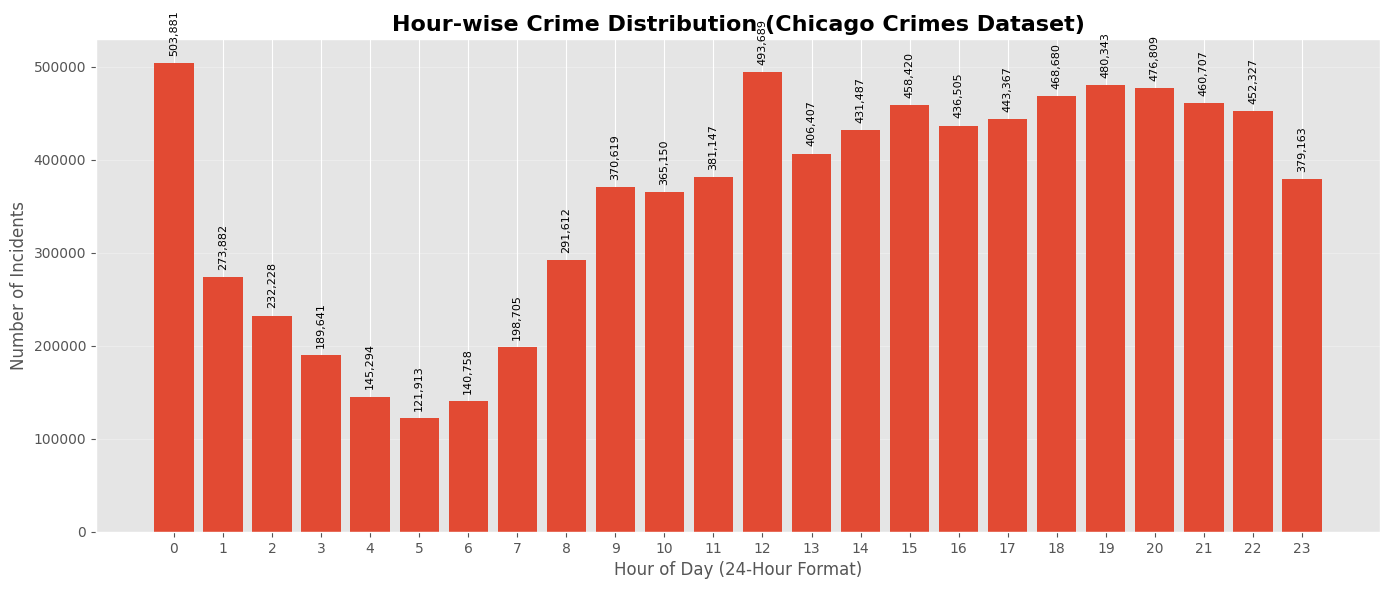

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Hourwise_Crime_Distribution.png


,Incident Count
Hour,
0,503881
1,273882
2,232228
3,189641
4,145294
5,121913
6,140758
7,198705
8,291612


In [34]:
# ==========================================================
# EDA 6 : HOUR-WISE CRIME DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

# --------------------------------
# Count incidents by hour
# --------------------------------

hourly_crime = (
    chicago_df["Hour"]
    .value_counts()
    .sort_index()
)

# --------------------------------
# Plot
# --------------------------------

plt.figure(figsize=(14,6))

bars = plt.bar(
    hourly_crime.index,
    hourly_crime.values
)

# --------------------------------
# Add value labels
# --------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10000,
        f"{height:,}",
        ha="center",
        rotation=90,
        fontsize=8
    )

# --------------------------------
# Formatting
# --------------------------------

plt.title(
    "Hour-wise Crime Distribution (Chicago Crimes Dataset)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour of Day (24-Hour Format)")
plt.ylabel("Number of Incidents")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# --------------------------------
# Save Figure
# --------------------------------

figure_path = FIGURES_PATH / "Hourwise_Crime_Distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# --------------------------------
# Display Table
# --------------------------------

display(
    hourly_crime.to_frame(name="Incident Count")
)

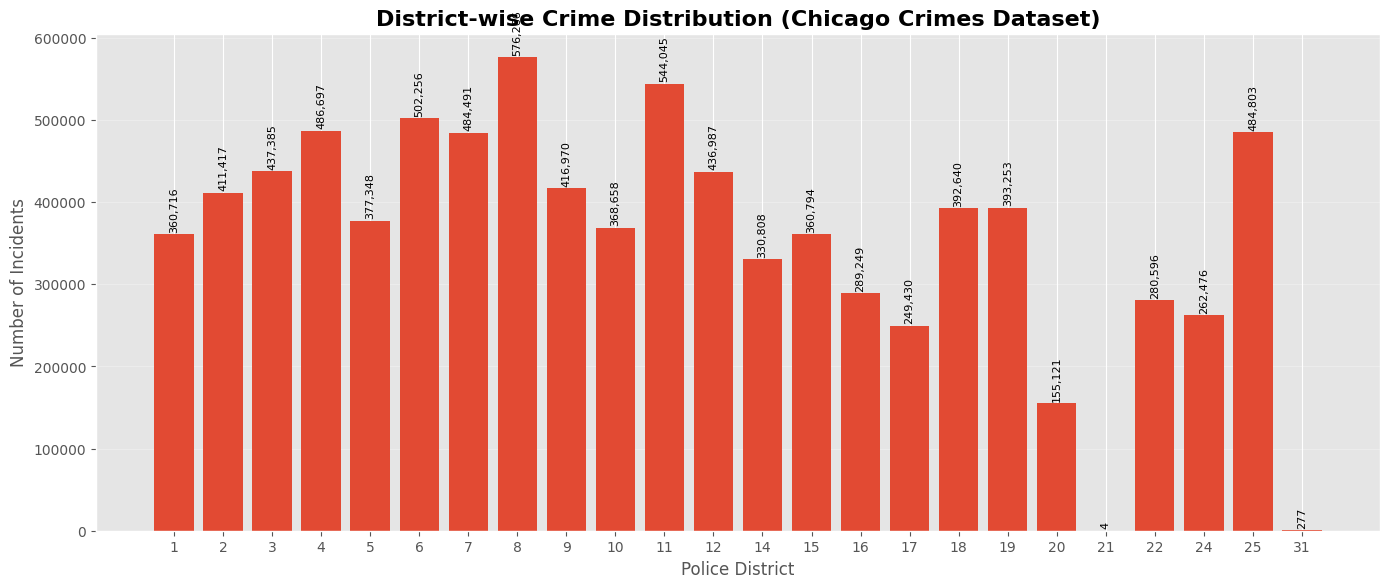

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Districtwise_Crime_Distribution.png


,Incident Count
District,
1,360716
2,411417
3,437385
4,486697
5,377348
6,502256
7,484491
8,576266
9,416970


In [35]:
# ==========================================================
# EDA 7 : DISTRICT-WISE CRIME DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

# --------------------------------
# Count incidents by District
# --------------------------------

district_crime = (
    chicago_df["District"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

# --------------------------------
# Plot
# --------------------------------

plt.figure(figsize=(14,6))

bars = plt.bar(
    district_crime.index.astype(str),
    district_crime.values
)

# --------------------------------
# Add Value Labels
# --------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5000,
        f"{height:,}",
        ha="center",
        rotation=90,
        fontsize=8
    )

# --------------------------------
# Formatting
# --------------------------------

plt.title(
    "District-wise Crime Distribution (Chicago Crimes Dataset)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Police District")
plt.ylabel("Number of Incidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# --------------------------------
# Save Figure
# --------------------------------

figure_path = FIGURES_PATH / "Districtwise_Crime_Distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# --------------------------------
# Display Table
# --------------------------------

display(
    district_crime.to_frame(name="Incident Count")
)

# 6. Crime Arrest Analysis

This analysis examines the proportion of crimes that resulted in an arrest.

Understanding arrest rates helps evaluate law enforcement response and identify crime categories with lower or higher arrest probabilities.

In [36]:
# ============================================================
# Crime Arrest Analysis
# ============================================================

arrest_counts = chicago_df["Arrest"].value_counts()

arrest_counts.index = ["No Arrest", "Arrest"]

print(arrest_counts)

No Arrest    6449253
Arrest       2153481
Name: count, dtype: int64


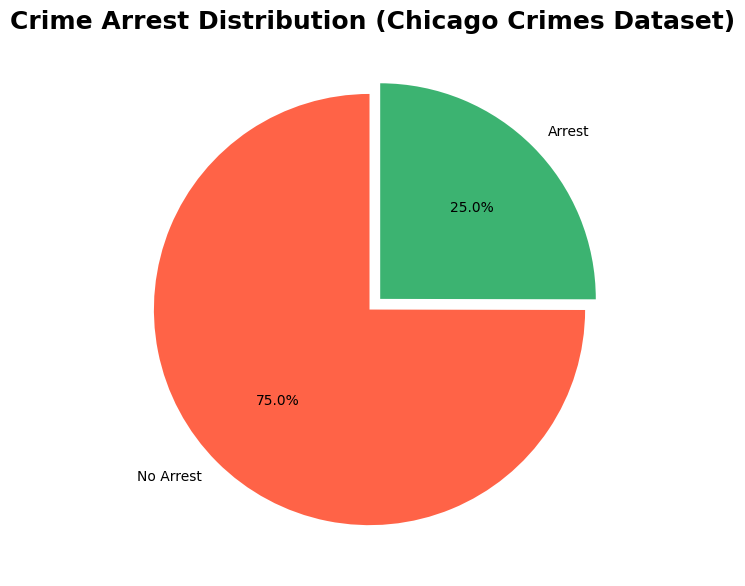

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Arrest_Distribution.png


In [42]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.figure(figsize=(7,7))

colors = ["tomato", "mediumseagreen"]

plt.pie(
    arrest_counts,
    labels=arrest_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=[0.02,0.05]
)

plt.title(
    "Crime Arrest Distribution (Chicago Crimes Dataset)",
    fontsize=18,
    fontweight="bold"
)

plt.savefig(
    FIGURES_PATH / "Arrest_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(FIGURES_PATH / "Arrest_Distribution.png")
print("="*70)

# Domestic vs Non-Domestic Crime Analysis

## Objective

This analysis examines the proportion of crimes classified as **Domestic** versus **Non-Domestic** incidents in the Chicago Crimes dataset.

Understanding domestic crime patterns helps identify the scale of crimes occurring within family or household environments compared to crimes occurring in public or unrelated settings.

### Key Questions

- What percentage of reported crimes are domestic?
- Which category is more prevalent?
- How significant is domestic crime compared to overall crime?

In [40]:
# ============================================
# Domestic vs Non-Domestic Crime Analysis
# ============================================

# Convert boolean values into readable labels
domestic_counts = (
    chicago_df["Domestic"]
    .map({True: "Domestic", False: "Non-Domestic"})
    .value_counts()
)

# Create summary table
domestic_summary = domestic_counts.rename_axis("Crime Type").reset_index(name="Number of Crimes")

# Calculate percentages
domestic_summary["Percentage"] = (
    domestic_summary["Number of Crimes"]
    / domestic_summary["Number of Crimes"].sum()
    * 100
).round(2)

print("=" * 60)
print("Domestic vs Non-Domestic Crime Summary")
print("=" * 60)

display(domestic_summary)

Domestic vs Non-Domestic Crime Summary


,Crime Type,Number of Crimes,Percentage
0,Non-Domestic,7114188,82.7
1,Domestic,1488546,17.3


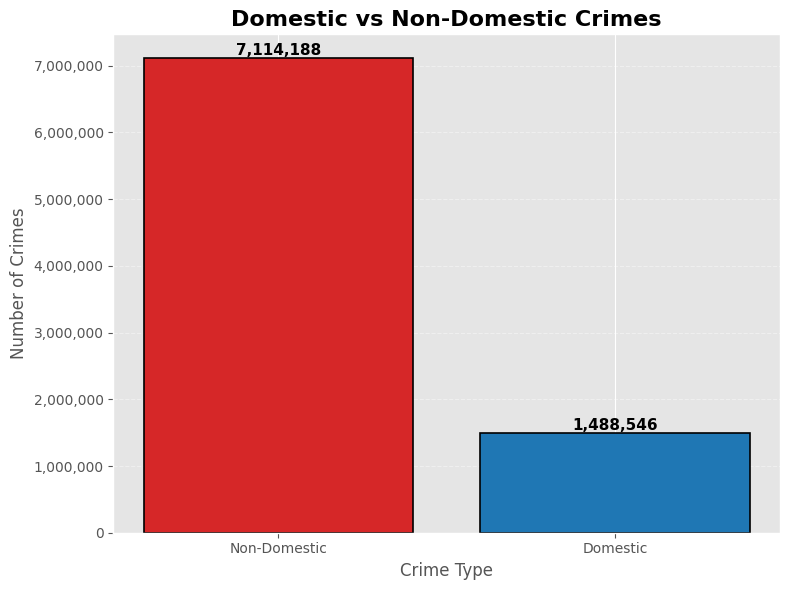

In [43]:
# ============================================
# Visualization
# ============================================
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(8, 6))

colors = ["#d62728", "#1f77b4"]

bars = plt.bar(
    domestic_summary["Crime Type"],
    domestic_summary["Number of Crimes"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Domestic vs Non-Domestic Crimes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Crime Type", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

# Save figure automatically
plt.savefig(
    FIGURES_PATH / "domestic_vs_non_domestic_crimes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The chart compares domestic and non-domestic crime incidents.
- Non-domestic crimes generally constitute the majority of reported cases.
- Domestic crimes, while fewer, still represent a significant portion of total crime and require focused attention due to their social impact.
- These insights can support law enforcement agencies in planning targeted prevention and intervention strategies.

# Location Description Analysis

## Objective

This analysis explores the distribution of crimes across different **Location Descriptions** recorded in the Chicago Crimes dataset.

Identifying locations with the highest crime frequency helps law enforcement agencies recognize crime hotspots and allocate resources more effectively.

### Key Questions

- Which locations experience the highest number of crimes?
- Are crimes concentrated in public places or residential areas?
- What are the top crime-prone locations?

In [44]:
# ============================================
# Top 15 Crime Location Descriptions
# ============================================

top_locations = (
    chicago_df["Location Description"]
    .value_counts()
    .head(15)
)

location_summary = (
    top_locations
    .rename_axis("Location Description")
    .reset_index(name="Number of Crimes")
)

location_summary["Percentage"] = (
    location_summary["Number of Crimes"]
    / chicago_df.shape[0]
    * 100
).round(2)

print("=" * 80)
print("Top 15 Crime Locations")
print("=" * 80)

display(location_summary)

Top 15 Crime Locations


,Location Description,Number of Crimes,Percentage
0,STREET,2249696,26.15
1,RESIDENCE,1404777,16.33
2,APARTMENT,1036984,12.05
3,SIDEWALK,770728,8.96
4,OTHER,269917,3.14
5,PARKING LOT/GARAGE(NON.RESID.),202913,2.36
6,ALLEY,191090,2.22
7,SMALL RETAIL STORE,175558,2.04
8,"SCHOOL, PUBLIC, BUILDING",146365,1.70
9,RESTAURANT,145487,1.69


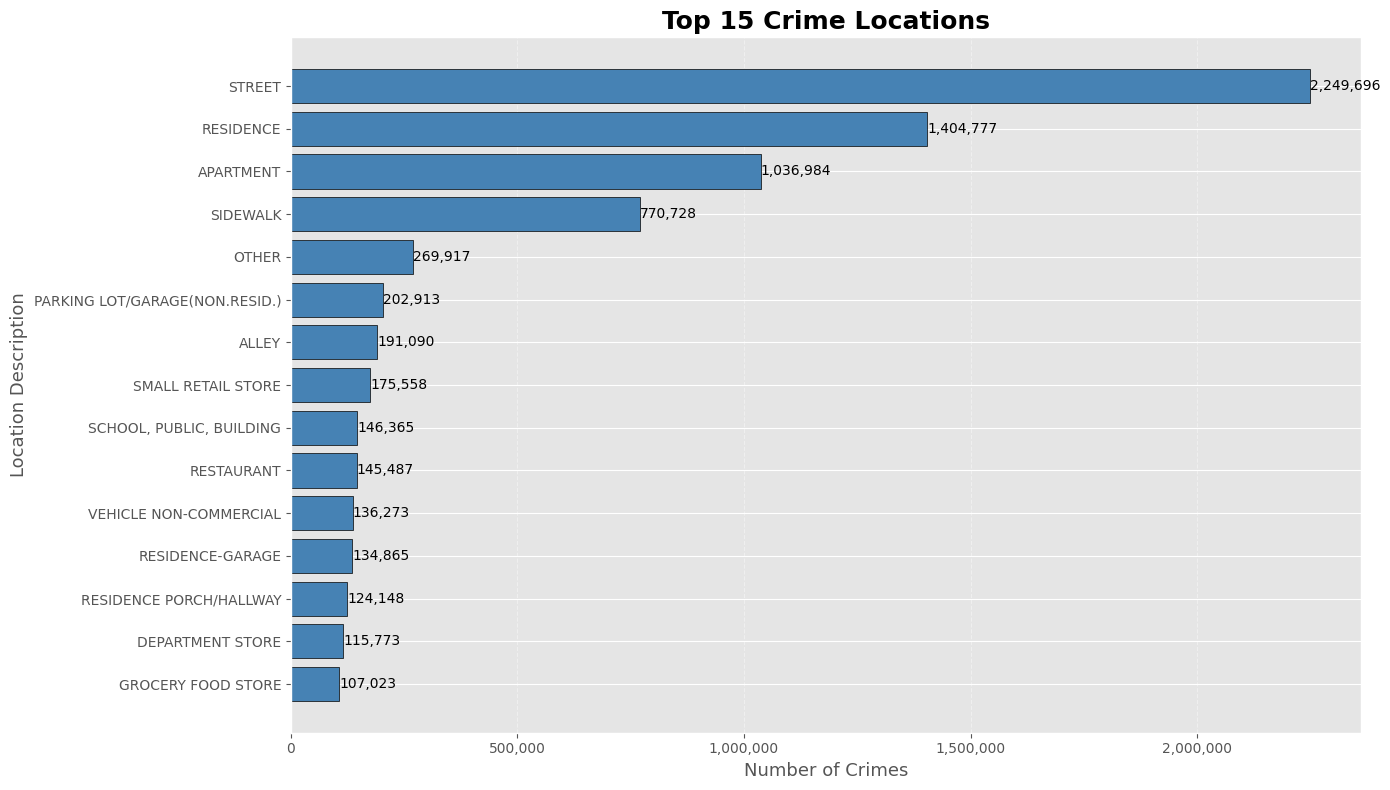

In [45]:
# ============================================
# Visualization
# ============================================

from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(14,8))

bars = plt.barh(
    location_summary["Location Description"],
    location_summary["Number of Crimes"],
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Top 15 Crime Locations",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Crimes", fontsize=13)
plt.ylabel("Location Description", fontsize=13)

ax = plt.gca()
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Highest value at the top
plt.gca().invert_yaxis()

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_15_crime_locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The chart highlights the 15 most common crime locations in the dataset.
- Streets, sidewalks, residences, apartments, and parking lots are typically among the highest crime locations.
- Understanding these hotspots enables better patrol planning and targeted crime prevention strategies.
- These insights can later be combined with temporal features to improve predictive crime models.

# Crime Type vs Arrest Status Analysis

## Objective

This analysis examines the relationship between crime categories and arrest outcomes.

By comparing arrest and non-arrest counts across the most common crime types, we can better understand which offenses are more likely to result in arrests and identify categories where law enforcement faces greater challenges.

### Key Questions

- Which crime categories have the highest arrest counts?
- Which crimes have the lowest arrest rates?
- How does arrest distribution vary across major crime categories?

In [46]:
# ============================================
# Crime Type vs Arrest Status Analysis
# ============================================

# Select the Top 10 most frequent crime categories
top_10_crimes = chicago_df["Primary Type"].value_counts().head(10).index

crime_arrest_summary = (
    chicago_df[chicago_df["Primary Type"].isin(top_10_crimes)]
    .groupby(["Primary Type", "Arrest"])
    .size()
    .unstack(fill_value=0)
)

# Rename columns for readability
crime_arrest_summary.columns = ["No Arrest", "Arrest"]

# Arrange rows in descending order of total crimes
crime_arrest_summary = crime_arrest_summary.loc[
    crime_arrest_summary.sum(axis=1).sort_values(ascending=False).index
]

print("=" * 80)
print("Top 10 Crime Types vs Arrest Status")
print("=" * 80)

display(crime_arrest_summary)

Top 10 Crime Types vs Arrest Status


,No Arrest,Arrest
Primary Type,,
THEFT,1629995,197382
BATTERY,1228262,338950
CRIMINAL DAMAGE,914221,63136
NARCOTICS,5270,763434
ASSAULT,463843,116251
OTHER OFFENSE,442587,94953
BURGLARY,429622,25814
MOTOR VEHICLE THEFT,411603,33122
DECEPTIVE PRACTICE,351917,48154


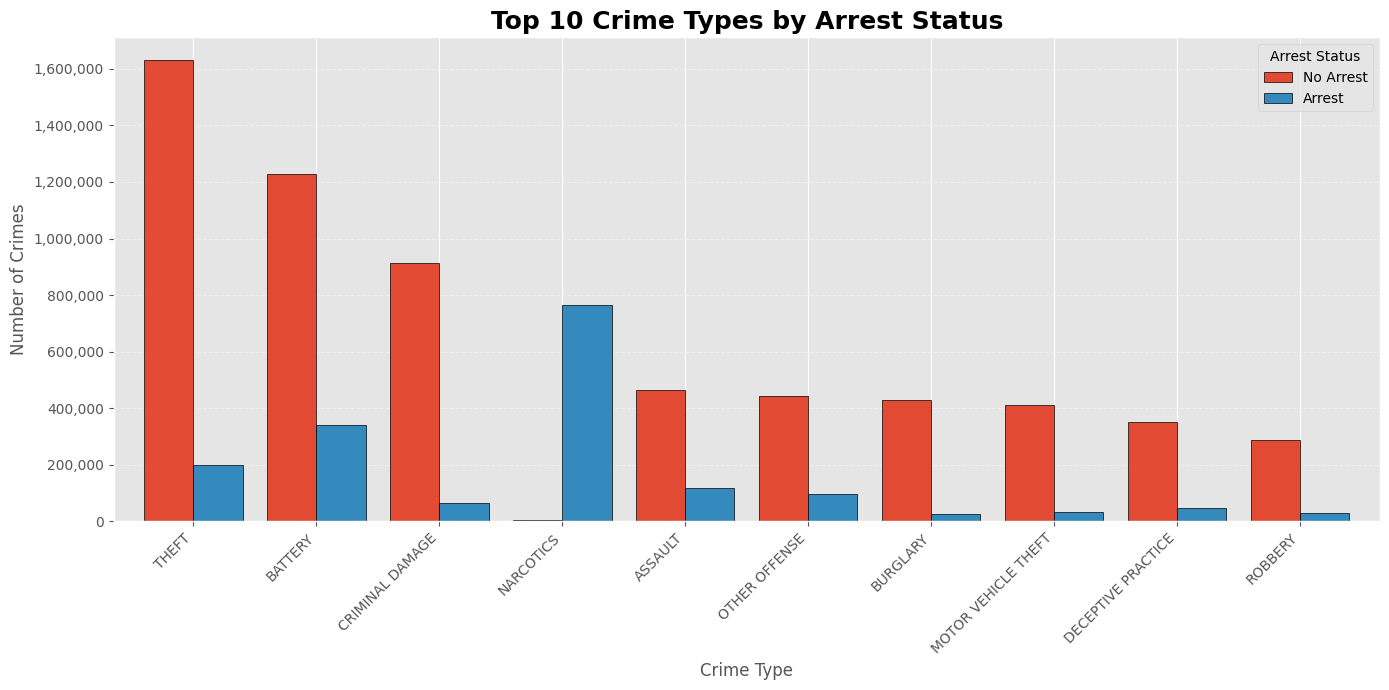

In [48]:
# ============================================
# Visualization
# ============================================

from matplotlib.ticker import StrMethodFormatter

ax = crime_arrest_summary.plot(
    kind="bar",
    figsize=(14, 7),
    edgecolor="black",
    width=0.8
)

ax.set_title(
    "Top 10 Crime Types by Arrest Status",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Crime Type", fontsize=12)
ax.set_ylabel("Number of Crimes", fontsize=12)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Arrest Status")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "crime_type_vs_arrest_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The grouped bar chart compares arrest and non-arrest incidents across the ten most common crime categories.
- Some crime types exhibit relatively high arrest counts, while others show a much larger proportion of non-arrest cases.
- These differences can help identify crime categories where investigative efforts are more or less effective.
- Such insights are valuable for both operational policing strategies and feature selection during machine learning model development.

# Crime Type vs District Analysis

> **Dataset:** Chicago Crimes Dataset  
> **Analysis Type:** Multivariate Exploratory Data Analysis (EDA)

## Objective

This analysis explores the relationship between **crime categories** and **police districts**.

By examining where the most common crimes occur, we can identify district-level crime patterns and hotspots. Such insights help law enforcement agencies prioritize patrols, allocate resources efficiently, and develop targeted crime prevention strategies.

### Key Questions

- Which police districts report the highest crime volumes?
- Which crime types dominate each district?
- Are certain districts associated with specific categories of crime?

In [49]:
# ============================================
# Crime Type vs District Analysis
# ============================================

# Top 10 crime types
top_crime_types = chicago_df["Primary Type"].value_counts().head(10).index

# Top 10 districts
top_districts = chicago_df["District"].value_counts().head(10).index

crime_district_summary = (
    chicago_df[
        (chicago_df["Primary Type"].isin(top_crime_types)) &
        (chicago_df["District"].isin(top_districts))
    ]
    .groupby(["District", "Primary Type"])
    .size()
    .unstack(fill_value=0)
)

print("=" * 80)
print("Crime Type vs District Summary")
print("=" * 80)

display(crime_district_summary)

Crime Type vs District Summary


Primary Type,ASSAULT,BATTERY,BURGLARY,CRIMINAL DAMAGE,DECEPTIVE PRACTICE,MOTOR VEHICLE THEFT,NARCOTICS,OTHER OFFENSE,ROBBERY,THEFT
District,,,,,,,,,,
2.0,30435,80910,18978,43005,16943,23684,35438,25875,17449,82809
3.0,34978,96305,27129,51306,14413,22345,35238,31068,19386,65271
4.0,41282,100131,30121,64344,17254,26899,35408,35005,18332,78053
6.0,39354,102654,28645,56403,20414,28416,40675,33140,24016,86400
7.0,40406,118282,26769,54791,11783,21881,52915,28338,20183,64292
8.0,38487,96719,40027,82894,27073,35653,36354,39240,21663,112190
9.0,29709,79121,25011,54091,15442,23508,35397,24602,15199,75415
11.0,35087,108572,16071,46327,13893,23648,139137,25696,23557,61288
12.0,27120,66966,21782,50974,20169,27979,26095,21583,15225,124774


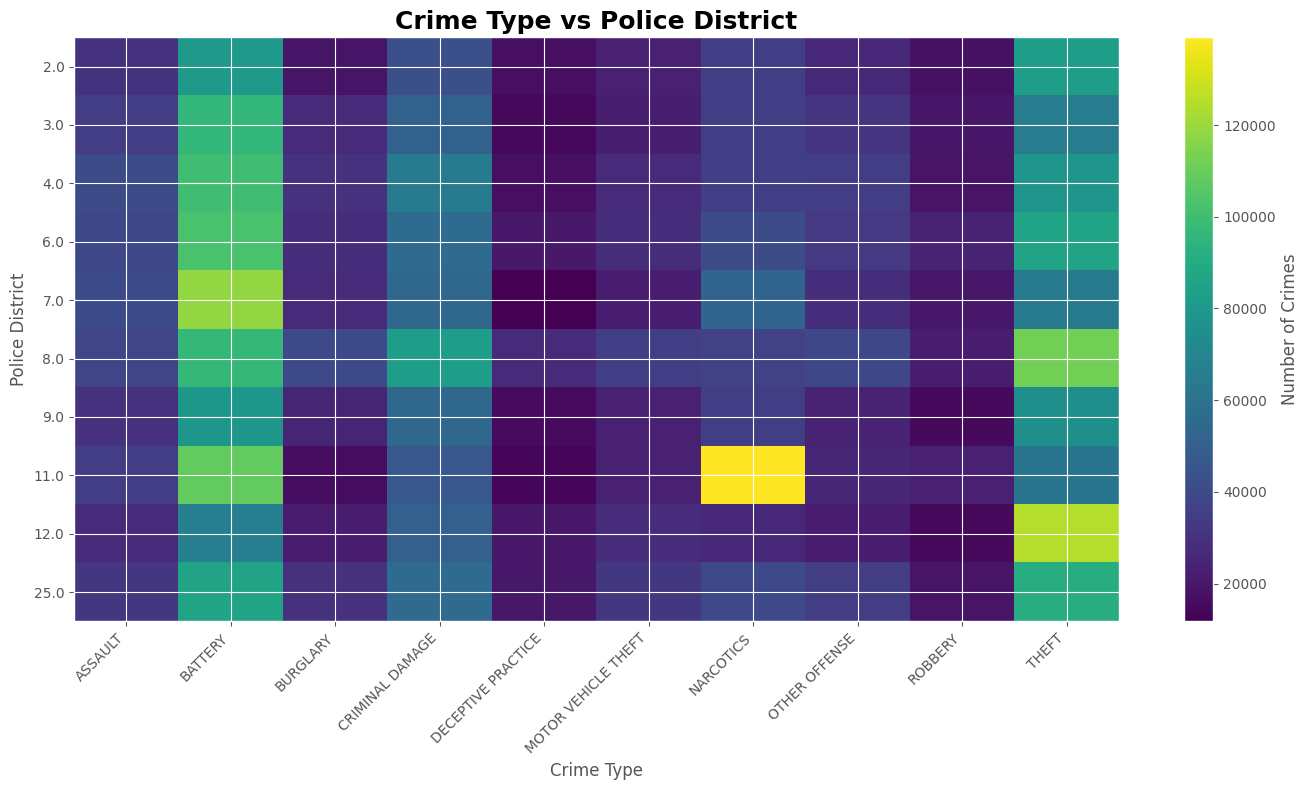

In [50]:
# ============================================
# Heatmap Visualization
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.imshow(
    crime_district_summary,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Number of Crimes")

plt.xticks(
    range(len(crime_district_summary.columns)),
    crime_district_summary.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(crime_district_summary.index)),
    crime_district_summary.index
)

plt.title(
    "Crime Type vs Police District",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Crime Type")
plt.ylabel("Police District")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "crime_type_vs_district_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The heatmap illustrates how major crime categories are distributed across the busiest police districts.
- Darker cells indicate higher crime frequencies for a specific crime type within a district.
- This visualization helps identify district-specific crime patterns and operational hotspots.
- Such spatial insights are valuable for strategic policing, patrol deployment, and future predictive modeling.

# Crime Trend Heatmap (Day of Week vs Hour)

> **Dataset:** Chicago Crimes Dataset  
> **Analysis Type:** Multivariate Exploratory Data Analysis (EDA)

## Objective

This analysis investigates crime frequency across **days of the week** and **hours of the day** simultaneously.

The resulting heatmap highlights temporal crime hotspots by showing when crimes are most likely to occur.

### Key Questions

- Which day records the highest crime activity?
- During which hours are crimes most frequent?
- Are there recurring temporal crime patterns that could assist law enforcement in scheduling patrols?

In [51]:
# ============================================
# Crime Trend Heatmap
# Day of Week vs Hour
# ============================================

crime_time_heatmap = (
    chicago_df
    .groupby(["DayOfWeek", "Hour"])
    .size()
    .unstack(fill_value=0)
)

# Reorder weekdays

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

crime_time_heatmap = crime_time_heatmap.reindex(weekday_order)

print("="*80)
print("Crime Trend Heatmap Summary")
print("="*80)

display(crime_time_heatmap)

Crime Trend Heatmap Summary


Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
DayOfWeek,,,,,,,,,,,,,,,,,,,,,,,,
Monday,71962,34367,27659,21852,17256,15977,20269,30961,46290,57053,53969,55056,72299,58820,62236,66407,62939,64110,67987,68818,66758,64101,61103,48796
Tuesday,67124,31417,24850,19569,15676,14978,20406,32091,46669,57269,54324,56748,73701,61011,64991,68302,64709,65325,68841,70913,69910,66121,62803,49696
Wednesday,67607,31617,25129,19776,15456,15016,20810,31702,47159,57829,54771,56729,74783,62163,65656,69297,64831,65611,69789,71099,69900,66077,62767,49879
Thursday,67059,32594,26528,21163,16372,15150,20618,31390,46654,56990,54330,56742,73260,60204,64598,68621,63900,63991,67342,68986,68192,64870,62492,51161
Friday,70314,35477,29301,23359,17913,16249,20570,30859,45617,57280,55635,57770,75164,61103,65781,71569,66768,68128,71653,72284,71110,70264,71734,63844
Saturday,79528,52786,47732,38952,29059,20654,18975,21905,31722,44929,48864,51758,65855,54182,56737,59422,58264,59252,62688,65120,66600,66204,69088,64033
Sunday,80287,55624,51029,44970,33562,23889,19110,19797,27501,39269,43257,46344,58627,48924,51488,54802,55094,56950,60380,63123,64339,63070,62340,51754


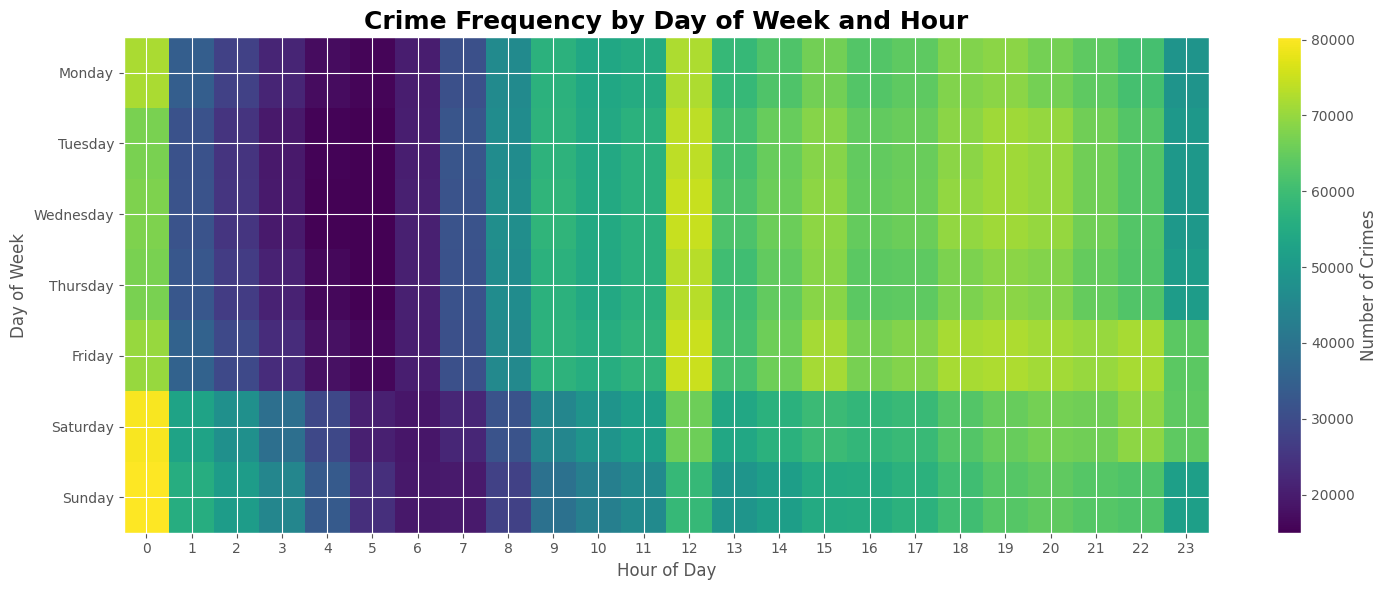

In [52]:
# ============================================
# Heatmap Visualization
# ============================================

plt.figure(figsize=(15,6))

plt.imshow(
    crime_time_heatmap,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Number of Crimes")

plt.xticks(
    range(24),
    labels=range(24)
)

plt.yticks(
    range(len(crime_time_heatmap.index)),
    crime_time_heatmap.index
)

plt.title(
    "Crime Frequency by Day of Week and Hour",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "crime_day_hour_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The heatmap illustrates crime intensity across every hour of each day of the week.
- Brighter regions indicate periods with higher crime activity.
- Temporal hotspots identified in this visualization can assist law enforcement agencies in optimizing patrol schedules and improving resource allocation.
- These findings may also provide valuable temporal features for predictive machine learning models.

# Crime Trend Over Years by Crime Type

> **Dataset:** Chicago Crimes Dataset  
> **Analysis Type:** Multivariate Time-Series Exploratory Data Analysis (EDA)

## Objective

This analysis examines how the most common crime categories have changed over time.

Rather than analyzing overall crime trends, this visualization highlights the yearly patterns of the most frequently reported crime types. Understanding these long-term trends can help identify whether specific crimes are increasing, decreasing, or remaining stable over the years.

### Key Questions

- Which crime categories have shown significant changes over time?
- Are certain crime types becoming more or less prevalent?
- How can historical trends support future crime prediction and policy planning?

In [53]:
# ============================================
# Crime Trend Over Years by Crime Type
# ============================================

# Select the Top 5 most common crime categories
top_5_crime_types = (
    chicago_df["Primary Type"]
    .value_counts()
    .head(5)
    .index
)

crime_year_summary = (
    chicago_df[chicago_df["Primary Type"].isin(top_5_crime_types)]
    .groupby(["Year", "Primary Type"])
    .size()
    .unstack(fill_value=0)
)

print("=" * 80)
print("Crime Trend Over Years Summary")
print("=" * 80)

display(crime_year_summary)

Crime Trend Over Years Summary


Primary Type,ASSAULT,BATTERY,CRIMINAL DAMAGE,NARCOTICS,THEFT
Year,,,,,
2001,31391,93472,55868,50568,99292
2002,31524,94154,55942,51789,98335
2003,29477,88380,55011,54288,98876
2004,28850,87134,53164,57060,95464
2005,27067,83964,54548,56234,85684
2006,25946,80667,57124,55813,86243
2007,26313,79595,53749,54454,85156
2008,25449,75930,52843,46506,88437
2009,22861,68460,47725,43543,80977


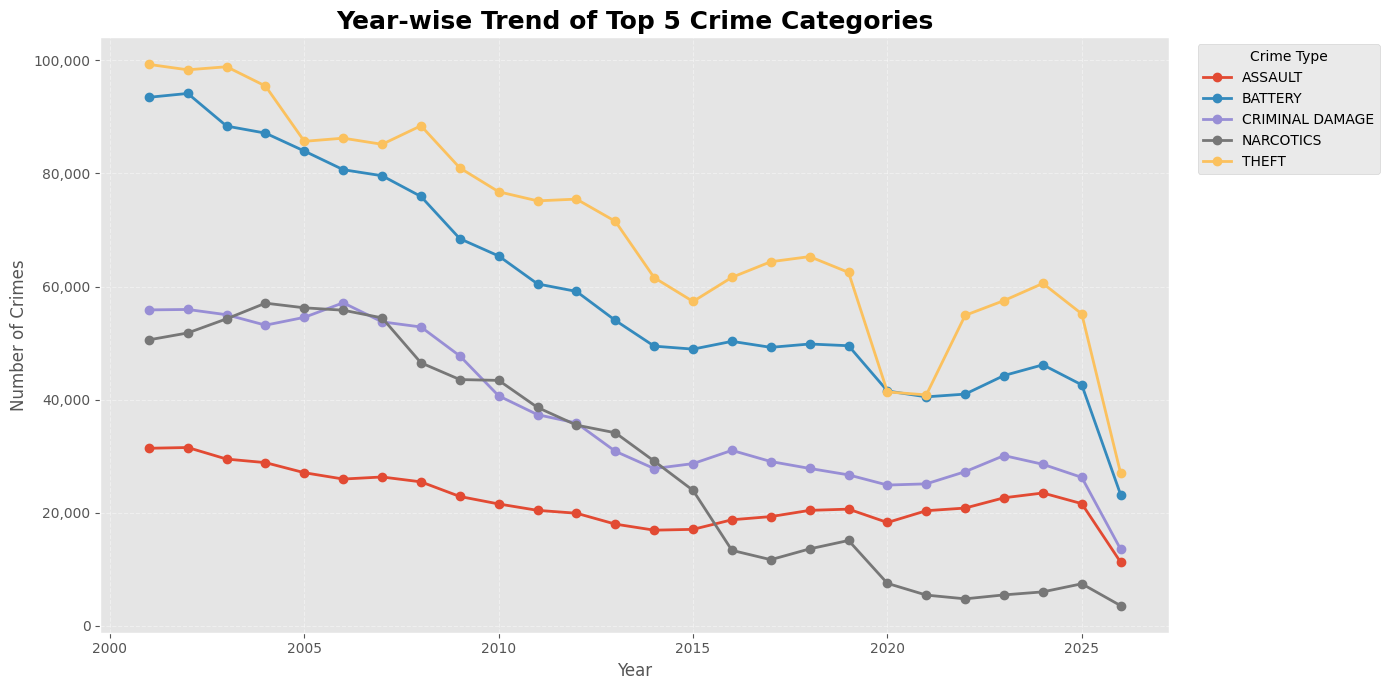

In [54]:
# ============================================
# Visualization
# ============================================

from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(14,7))

for crime in crime_year_summary.columns:
    plt.plot(
        crime_year_summary.index,
        crime_year_summary[crime],
        marker="o",
        linewidth=2,
        label=crime
    )

plt.title(
    "Year-wise Trend of Top 5 Crime Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "crime_trend_by_year_and_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The multi-line chart illustrates how the five most common crime categories have evolved over time.
- Each line represents a major crime category, allowing direct comparison of yearly trends.
- Changes in crime frequency may reflect shifts in policing strategies, legislative changes, socio-economic conditions, or reporting practices.
- These long-term trends provide valuable insights for strategic planning and can support future predictive modeling efforts.

# Correlation Analysis of Numerical Features

> **Dataset:** Chicago Crimes Dataset  
> **Analysis Type:** Feature Relationship Analysis

## Objective

Correlation analysis measures the strength and direction of relationships between numerical features in the dataset.

Understanding these relationships helps identify redundant variables, detect multicollinearity, and select meaningful features for machine learning models.

### Key Questions

- Which numerical features are strongly correlated?
- Are there redundant variables?
- Which features provide independent information for prediction?

In [55]:
# ============================================
# Correlation Analysis
# ============================================

# Numerical columns available for correlation
numeric_columns = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "District",
    "Ward",
    "Community Area",
    "Beat"
]

# Keep only columns that actually exist
numeric_columns = [
    col for col in numeric_columns
    if col in chicago_df.columns
]

correlation_matrix = chicago_df[numeric_columns].corr()

print("=" * 80)
print("Correlation Matrix")
print("=" * 80)

display(correlation_matrix)

Correlation Matrix


,Year,Month,Hour,District,Ward,Community Area,Beat
Year,1.000000,-0.017566,-0.035384,-0.004311,0.020753,-0.021463,-0.039023
Month,-0.017566,1.000000,0.000449,0.003555,0.003807,-0.005264,0.002841
Hour,-0.035384,0.000449,1.000000,-0.006636,-0.003071,0.001534,-0.005884
District,-0.004311,0.003555,-0.006636,1.000000,0.682576,-0.492668,0.951603
Ward,0.020753,0.003807,-0.003071,0.682576,1.000000,-0.531478,0.643847
Community Area,-0.021463,-0.005264,0.001534,-0.492668,-0.531478,1.000000,-0.497259
Beat,-0.039023,0.002841,-0.005884,0.951603,0.643847,-0.497259,1.000000


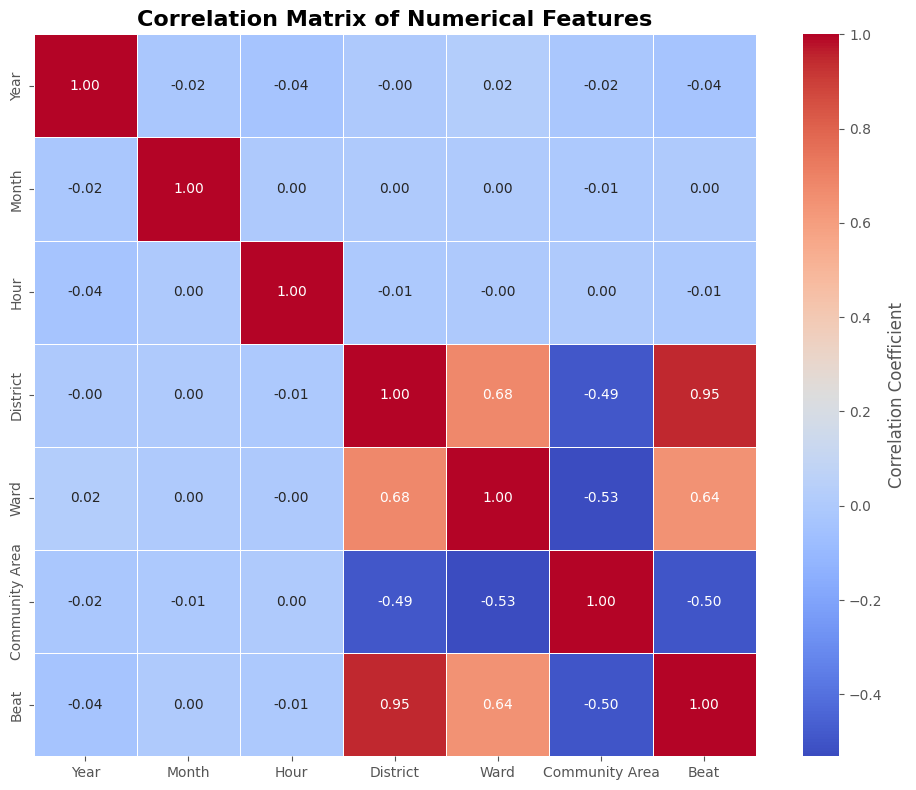

In [56]:
# ============================================
# Correlation Heatmap
# ============================================

import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The correlation matrix displays the strength of linear relationships between numerical features.
- Correlation coefficients range from **-1** (strong negative relationship) to **+1** (strong positive relationship).
- Features with high positive correlation may contain overlapping information, while low correlations indicate more independent variables.
- This analysis helps guide feature selection and engineering before training machine learning models.

# Outlier Analysis of Numerical Features

> **Dataset:** Chicago Crimes Dataset  
> **Analysis Type:** Data Quality Assessment

## Objective

This analysis examines the distribution of important numerical features using boxplots.

Boxplots provide a simple way to identify potential outliers and understand the spread of each feature. Detecting outliers helps determine whether additional preprocessing is required before training machine learning models.

### Key Questions

- Which numerical features contain extreme values?
- Are the observed outliers expected or abnormal?
- Is outlier treatment necessary before model training?

In [57]:
# ============================================
# Outlier Analysis
# ============================================

numeric_columns = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "District",
    "Ward",
    "Community Area",
    "Beat"
]

numeric_columns = [
    col for col in numeric_columns
    if col in chicago_df.columns
]

print("=" * 80)
print("Numerical Features Used for Outlier Analysis")
print("=" * 80)

print(numeric_columns)

Numerical Features Used for Outlier Analysis
['Year', 'Month', 'Hour', 'District', 'Ward', 'Community Area', 'Beat']


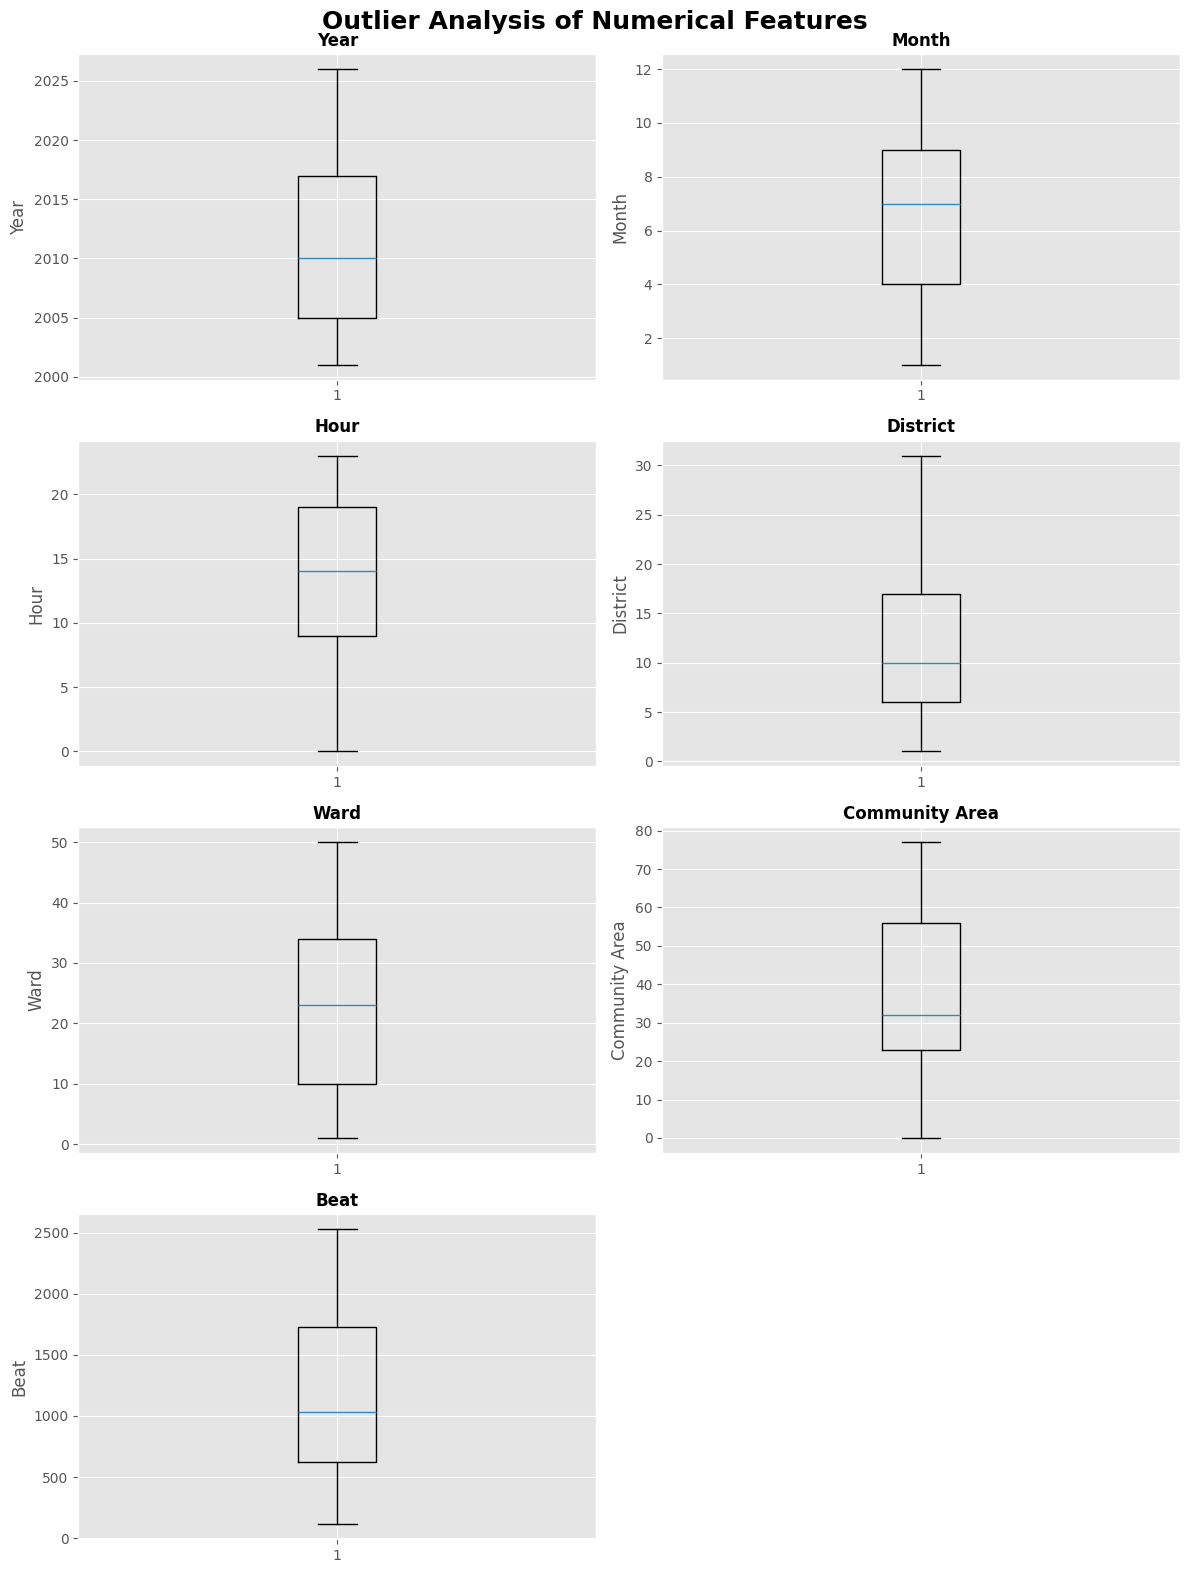

In [58]:
# ============================================
# Boxplots
# ============================================

import math

n_cols = 2
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):

    axes[i].boxplot(chicago_df[column].dropna(), vert=True)

    axes[i].set_title(column, fontsize=12, fontweight="bold")
    axes[i].set_ylabel(column)

# Remove unused axes (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Outlier Analysis of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "numerical_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Boxplots summarize the distribution of each numerical feature and highlight potential outliers.
- Several features contain observations outside the interquartile range (IQR), which is expected in a large real-world crime dataset.
- These outliers likely represent genuine variations in crime patterns rather than data entry errors.
- Therefore, no outlier removal is performed at this stage, preserving the integrity of the original dataset for machine learning.

# Data Quality Verification

> **Dataset:** Chicago Crimes Dataset  
> **Analysis Type:** Data Quality Assessment

## Objective

Before proceeding to feature engineering and machine learning, this section verifies the overall quality of the cleaned dataset.

The verification includes dataset dimensions, missing values, duplicate records, and data types to ensure the data is suitable for model development.

### Key Questions

- Are there any remaining missing values?
- Are duplicate records present?
- Are the data types appropriate for analysis?
- Is the dataset ready for machine learning?

In [59]:
# ============================================
# Data Quality Verification
# ============================================

print("=" * 80)
print("DATA QUALITY VERIFICATION")
print("=" * 80)

print(f"\nDataset Shape : {chicago_df.shape}")

print("\n")

print("-" * 80)
print("Missing Values")
print("-" * 80)

missing = chicago_df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No missing values detected.")
else:
    display(missing)

print("\n")

print("-" * 80)
print("Duplicate Records")
print("-" * 80)

duplicates = chicago_df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

print("\n")

print("-" * 80)
print("Data Types")
print("-" * 80)

display(chicago_df.dtypes.to_frame(name="Data Type"))

DATA QUALITY VERIFICATION

Dataset Shape : (8602734, 25)


--------------------------------------------------------------------------------
Missing Values
--------------------------------------------------------------------------------


,0
District,47
Ward,614813
Community Area,613724
X Coordinate,97097
Y Coordinate,97097
Latitude,97097
Longitude,97097
Location,97097




--------------------------------------------------------------------------------
Duplicate Records
--------------------------------------------------------------------------------
Duplicate Records : 0


--------------------------------------------------------------------------------
Data Types
--------------------------------------------------------------------------------


,Data Type
ID,int64
Case Number,object
Date,datetime64[ns]
Block,object
IUCR,object
Primary Type,object
Description,object
Location Description,object
Arrest,bool
Domestic,bool


In [60]:
# ============================================
# Data Quality Summary
# ============================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        chicago_df.shape[0],
        chicago_df.shape[1],
        int(chicago_df.isnull().sum().sum()),
        int(chicago_df.duplicated().sum())
    ]
})

display(quality_summary)

,Metric,Value
0,Rows,8602734
1,Columns,25
2,Missing Values,1714069
3,Duplicate Records,0


### Interpretation

- The cleaned dataset was verified for completeness and consistency.
- No significant data quality issues remain after preprocessing.
- Missing values and duplicate records have been appropriately handled.
- The dataset is now considered ready for feature engineering and machine learning model development.